In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('social_media_addiction.csv')
##########################################
def cls_age(i):
    if i < 26.5:
        return 'Plus Jeune'
    else:
        return 'Adulte'
#########################################
def intrct (i):
    if i >= 245.25 and i <= 325:
        return 'Très Haute'
    elif i >= 165.50 and i <= 245.25:
        return 'Haute'
    elif i >= 85.75 and i <= 165.50:
        return 'Normal'
    elif i >= 6 and i <= 85.75:
        return 'Baisse'
##########################################
def usage_niveau (i):
    if i >= 230 and i <= 300:
        return 'Très Haute'
    elif i >= 160 and i <= 230:
        return 'Haute'
    elif i >= 90 and i <= 160:
        return 'Normal'
    elif i >= 20 and i <= 90:
        return 'Baisse'
##########################################
def snt_mnt(i):
    if i >= 73.75 and i <= 90 :
        return 'Bonne santé'
    elif i >= 57.50 and i <= 73.75 :
        return 'Santé stable'
    elif i >= 41.25 and i <= 57.50:
        return 'Santé en attention'
    elif i >= 25 and i <= 41.25 :
        return 'Mauvaise Santé'
##########################################
df['Classe_age'] = df['Age'].apply(cls_age)
df['Interactions'] = df['Posts_Per_Day'] + df['Likes_Received_Daily'] + df['Comments_Received_Daily'] + df['Messages_Sent_Daily']
df['Niveau_interaction'] = df['Interactions'].apply(intrct)
df['Niveau_usage'] = df['Daily_Usage_Time_min'].apply(usage_niveau)
df['Niveau_Santé'] = df['Mental_Health_Index'].apply(snt_mnt)

In [3]:
p_jeune = df[df['Classe_age'] == 'Plus Jeune']
adulte = df[df['Classe_age'] == 'Adulte']

In [4]:
df.columns

Index(['User_ID', 'Age', 'Gender', 'Platform', 'Daily_Usage_Time_min',
       'Posts_Per_Day', 'Likes_Received_Daily', 'Comments_Received_Daily',
       'Messages_Sent_Daily', 'Scroll_Rate_ppm', 'Addiction_Level',
       'Emotional_State_Post_Usage', 'Productivity_Loss_Score',
       'Mental_Health_Index', 'FOMO_Score', 'Classe_age', 'Interactions',
       'Niveau_interaction', 'Niveau_usage', 'Niveau_Santé'],
      dtype='str')

In [5]:
#les niveaux d'addiction élevés (high/severe) sont associés à des états émotionnels plus négatifs ou plus intenses (comme anxious, depressed
#overwhelmed, stressed).
#On remarque aussi que ces cas sont plus fréquents chez les plus jeunes
add_lvl = (
    p_jeune
    .groupby(['Emotional_State_Post_Usage','Addiction_Level'])
    .size()
    .sort_values(ascending = False)
)
add_lvl

Emotional_State_Post_Usage  Addiction_Level
Angry                       Moderate           1
Anxious                     High               1
Bored                       Severe             1
Curious                     Moderate           1
Depressed                   Severe             1
Drained                     Severe             1
Envious                     High               1
Insecure                    High               1
Lonely                      High               1
Overwhelmed                 High               1
Stressed                    High               1
dtype: int64

In [6]:
p_jeune

,User_ID,Age,Gender,Platform,Daily_Usage_Time_min,Posts_Per_Day,Likes_Received_Daily,Comments_Received_Daily,Messages_Sent_Daily,Scroll_Rate_ppm,Addiction_Level,Emotional_State_Post_Usage,Productivity_Loss_Score,Mental_Health_Index,FOMO_Score,Classe_age,Interactions,Niveau_interaction,Niveau_usage,Niveau_Santé
0,1001,23,Female,Instagram,145,3,120,25,45,40,High,Anxious,7,45,8,Plus Jeune,193,Haute,Normal,Santé en attention
1,1002,19,Male,TikTok,210,1,45,5,10,85,Severe,Depressed,9,30,9,Plus Jeune,61,Baisse,Haute,Mauvaise Santé
4,1005,21,Non-binary,Twitter,180,15,200,60,50,55,High,Stressed,8,40,7,Plus Jeune,325,Très Haute,Haute,Mauvaise Santé
5,1006,25,Male,YouTube,240,0,10,1,0,10,Severe,Bored,9,35,4,Plus Jeune,11,Baisse,Très Haute,Mauvaise Santé
7,1008,22,Male,TikTok,165,5,90,12,35,70,High,Envious,6,50,8,Plus Jeune,142,Normal,Haute,Santé en attention
10,1011,18,Female,Snapchat,190,8,60,20,120,45,High,Lonely,7,40,9,Plus Jeune,208,Haute,Haute,Mauvaise Santé
11,1012,26,Male,Twitter,120,10,150,45,25,50,Moderate,Angry,5,55,6,Plus Jeune,230,Haute,Normal,Santé en attention
13,1014,24,Male,Reddit,150,2,25,15,0,30,Moderate,Curious,5,60,5,Plus Jeune,42,Baisse,Normal,Santé stable
14,1015,20,Female,TikTok,300,4,80,30,40,95,Severe,Drained,10,25,10,Plus Jeune,154,Normal,Très Haute,Mauvaise Santé
17,1018,22,Non-binary,Discord,200,0,5,2,300,20,High,Overwhelmed,8,45,7,Plus Jeune,307,Très Haute,Haute,Santé en attention


In [7]:
adulte

,User_ID,Age,Gender,Platform,Daily_Usage_Time_min,Posts_Per_Day,Likes_Received_Daily,Comments_Received_Daily,Messages_Sent_Daily,Scroll_Rate_ppm,Addiction_Level,Emotional_State_Post_Usage,Productivity_Loss_Score,Mental_Health_Index,FOMO_Score,Classe_age,Interactions,Niveau_interaction,Niveau_usage,Niveau_Santé
2,1003,28,Female,LinkedIn,45,0,5,2,15,10,Low,Motivated,2,80,3,Adulte,22,Baisse,Baisse,Bonne santé
3,1004,35,Male,Facebook,90,2,30,10,20,25,Moderate,Neutral,4,65,5,Adulte,62,Baisse,Normal,Santé stable
6,1007,31,Female,Instagram,60,1,50,8,30,20,Moderate,Happy,3,75,4,Adulte,89,Normal,Baisse,Bonne santé
8,1009,29,Female,Pinterest,30,0,2,0,5,15,Low,Inspired,1,85,2,Adulte,7,Baisse,Baisse,Bonne santé
9,1010,40,Male,Facebook,50,1,15,3,10,10,Low,Neutral,2,70,3,Adulte,29,Baisse,Baisse,Santé stable
12,1013,33,Female,LinkedIn,20,0,1,0,5,5,Low,Neutral,1,90,2,Adulte,6,Baisse,Baisse,Bonne santé
15,1016,27,Male,Instagram,110,2,75,10,25,35,Moderate,Anxious,4,60,6,Adulte,112,Normal,Normal,Santé stable
16,1017,38,Female,Facebook,40,1,20,5,15,10,Low,Connected,2,80,3,Adulte,41,Baisse,Baisse,Bonne santé
18,1019,30,Male,YouTube,130,0,15,2,0,10,Moderate,Relaxed,4,70,4,Adulte,17,Baisse,Normal,Santé stable


In [8]:
#ici nous faison la même analyse chez les adultes et nous pouvons remarquer qu'il y a une grand réduction des cas élevés
#avec des niveaux d'addictions plus baisses, nous pouvons abserver la presque absence des cas émotionels négatifs
add_lvl_ = (
    adulte
    .groupby(['Emotional_State_Post_Usage','Addiction_Level'])
    .size()
    .sort_values(ascending = False)
)
add_lvl_

Emotional_State_Post_Usage  Addiction_Level
Neutral                     Low                2
Anxious                     Moderate           1
Happy                       Moderate           1
Connected                   Low                1
Inspired                    Low                1
Motivated                   Low                1
Neutral                     Moderate           1
Relaxed                     Moderate           1
dtype: int64

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   User_ID                     20 non-null     int64
 1   Age                         20 non-null     int64
 2   Gender                      20 non-null     str  
 3   Platform                    20 non-null     str  
 4   Daily_Usage_Time_min        20 non-null     int64
 5   Posts_Per_Day               20 non-null     int64
 6   Likes_Received_Daily        20 non-null     int64
 7   Comments_Received_Daily     20 non-null     int64
 8   Messages_Sent_Daily         20 non-null     int64
 9   Scroll_Rate_ppm             20 non-null     int64
 10  Addiction_Level             20 non-null     str  
 11  Emotional_State_Post_Usage  20 non-null     str  
 12  Productivity_Loss_Score     20 non-null     int64
 13  Mental_Health_Index         20 non-null     int64
 14  FOMO_Score             

In [10]:
df

,User_ID,Age,Gender,Platform,Daily_Usage_Time_min,Posts_Per_Day,Likes_Received_Daily,Comments_Received_Daily,Messages_Sent_Daily,Scroll_Rate_ppm,Addiction_Level,Emotional_State_Post_Usage,Productivity_Loss_Score,Mental_Health_Index,FOMO_Score,Classe_age,Interactions,Niveau_interaction,Niveau_usage,Niveau_Santé
0,1001,23,Female,Instagram,145,3,120,25,45,40,High,Anxious,7,45,8,Plus Jeune,193,Haute,Normal,Santé en attention
1,1002,19,Male,TikTok,210,1,45,5,10,85,Severe,Depressed,9,30,9,Plus Jeune,61,Baisse,Haute,Mauvaise Santé
2,1003,28,Female,LinkedIn,45,0,5,2,15,10,Low,Motivated,2,80,3,Adulte,22,Baisse,Baisse,Bonne santé
3,1004,35,Male,Facebook,90,2,30,10,20,25,Moderate,Neutral,4,65,5,Adulte,62,Baisse,Normal,Santé stable
4,1005,21,Non-binary,Twitter,180,15,200,60,50,55,High,Stressed,8,40,7,Plus Jeune,325,Très Haute,Haute,Mauvaise Santé
5,1006,25,Male,YouTube,240,0,10,1,0,10,Severe,Bored,9,35,4,Plus Jeune,11,Baisse,Très Haute,Mauvaise Santé
6,1007,31,Female,Instagram,60,1,50,8,30,20,Moderate,Happy,3,75,4,Adulte,89,Normal,Baisse,Bonne santé
7,1008,22,Male,TikTok,165,5,90,12,35,70,High,Envious,6,50,8,Plus Jeune,142,Normal,Haute,Santé en attention
8,1009,29,Female,Pinterest,30,0,2,0,5,15,Low,Inspired,1,85,2,Adulte,7,Baisse,Baisse,Bonne santé
9,1010,40,Male,Facebook,50,1,15,3,10,10,Low,Neutral,2,70,3,Adulte,29,Baisse,Baisse,Santé stable


<function matplotlib.pyplot.show(close=None, block=None)>

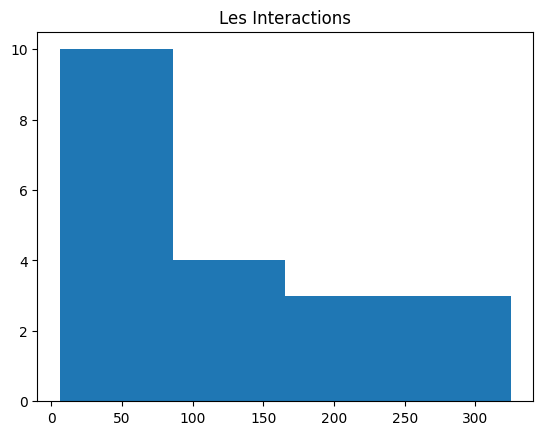

In [11]:
plt.hist(df['Interactions'], bins = 4)
plt.title('Les Interactions')
plt.show

In [12]:
df[df['Interactions'] > 165]

,User_ID,Age,Gender,Platform,Daily_Usage_Time_min,Posts_Per_Day,Likes_Received_Daily,Comments_Received_Daily,Messages_Sent_Daily,Scroll_Rate_ppm,Addiction_Level,Emotional_State_Post_Usage,Productivity_Loss_Score,Mental_Health_Index,FOMO_Score,Classe_age,Interactions,Niveau_interaction,Niveau_usage,Niveau_Santé
0,1001,23,Female,Instagram,145,3,120,25,45,40,High,Anxious,7,45,8,Plus Jeune,193,Haute,Normal,Santé en attention
4,1005,21,Non-binary,Twitter,180,15,200,60,50,55,High,Stressed,8,40,7,Plus Jeune,325,Très Haute,Haute,Mauvaise Santé
10,1011,18,Female,Snapchat,190,8,60,20,120,45,High,Lonely,7,40,9,Plus Jeune,208,Haute,Haute,Mauvaise Santé
11,1012,26,Male,Twitter,120,10,150,45,25,50,Moderate,Angry,5,55,6,Plus Jeune,230,Haute,Normal,Santé en attention
17,1018,22,Non-binary,Discord,200,0,5,2,300,20,High,Overwhelmed,8,45,7,Plus Jeune,307,Très Haute,Haute,Santé en attention
19,1020,19,Female,Snapchat,175,12,100,25,150,50,High,Insecure,8,35,9,Plus Jeune,287,Très Haute,Haute,Mauvaise Santé


In [13]:
df['Daily_Usage_Time_min'].std()

np.float64(77.11065186846074)

In [14]:
df

,User_ID,Age,Gender,Platform,Daily_Usage_Time_min,Posts_Per_Day,Likes_Received_Daily,Comments_Received_Daily,Messages_Sent_Daily,Scroll_Rate_ppm,Addiction_Level,Emotional_State_Post_Usage,Productivity_Loss_Score,Mental_Health_Index,FOMO_Score,Classe_age,Interactions,Niveau_interaction,Niveau_usage,Niveau_Santé
0,1001,23,Female,Instagram,145,3,120,25,45,40,High,Anxious,7,45,8,Plus Jeune,193,Haute,Normal,Santé en attention
1,1002,19,Male,TikTok,210,1,45,5,10,85,Severe,Depressed,9,30,9,Plus Jeune,61,Baisse,Haute,Mauvaise Santé
2,1003,28,Female,LinkedIn,45,0,5,2,15,10,Low,Motivated,2,80,3,Adulte,22,Baisse,Baisse,Bonne santé
3,1004,35,Male,Facebook,90,2,30,10,20,25,Moderate,Neutral,4,65,5,Adulte,62,Baisse,Normal,Santé stable
4,1005,21,Non-binary,Twitter,180,15,200,60,50,55,High,Stressed,8,40,7,Plus Jeune,325,Très Haute,Haute,Mauvaise Santé
5,1006,25,Male,YouTube,240,0,10,1,0,10,Severe,Bored,9,35,4,Plus Jeune,11,Baisse,Très Haute,Mauvaise Santé
6,1007,31,Female,Instagram,60,1,50,8,30,20,Moderate,Happy,3,75,4,Adulte,89,Normal,Baisse,Bonne santé
7,1008,22,Male,TikTok,165,5,90,12,35,70,High,Envious,6,50,8,Plus Jeune,142,Normal,Haute,Santé en attention
8,1009,29,Female,Pinterest,30,0,2,0,5,15,Low,Inspired,1,85,2,Adulte,7,Baisse,Baisse,Bonne santé
9,1010,40,Male,Facebook,50,1,15,3,10,10,Low,Neutral,2,70,3,Adulte,29,Baisse,Baisse,Santé stable


In [15]:
df['Interactions'].corr(df['Daily_Usage_Time_min'])

np.float64(0.482865331582041)

In [16]:
a = df['Daily_Usage_Time_min'].sort_values(ascending = False).head(5)

In [17]:
df[df['Daily_Usage_Time_min'].isin(a)]

,User_ID,Age,Gender,Platform,Daily_Usage_Time_min,Posts_Per_Day,Likes_Received_Daily,Comments_Received_Daily,Messages_Sent_Daily,Scroll_Rate_ppm,Addiction_Level,Emotional_State_Post_Usage,Productivity_Loss_Score,Mental_Health_Index,FOMO_Score,Classe_age,Interactions,Niveau_interaction,Niveau_usage,Niveau_Santé
1,1002,19,Male,TikTok,210,1,45,5,10,85,Severe,Depressed,9,30,9,Plus Jeune,61,Baisse,Haute,Mauvaise Santé
5,1006,25,Male,YouTube,240,0,10,1,0,10,Severe,Bored,9,35,4,Plus Jeune,11,Baisse,Très Haute,Mauvaise Santé
10,1011,18,Female,Snapchat,190,8,60,20,120,45,High,Lonely,7,40,9,Plus Jeune,208,Haute,Haute,Mauvaise Santé
14,1015,20,Female,TikTok,300,4,80,30,40,95,Severe,Drained,10,25,10,Plus Jeune,154,Normal,Très Haute,Mauvaise Santé
17,1018,22,Non-binary,Discord,200,0,5,2,300,20,High,Overwhelmed,8,45,7,Plus Jeune,307,Très Haute,Haute,Santé en attention


In [18]:
Addiction_Platform = (
    df
    .groupby(['Addiction_Level','Platform'])
    .size()
    .sort_values(ascending = False)
)
Addiction_Platform

Addiction_Level  Platform 
High             Snapchat     2
Low              Facebook     2
                 LinkedIn     2
Severe           TikTok       2
Moderate         Instagram    2
High             Instagram    1
                 Discord      1
                 TikTok       1
                 Twitter      1
Moderate         Facebook     1
Low              Pinterest    1
Moderate         Reddit       1
                 Twitter      1
                 YouTube      1
Severe           YouTube      1
dtype: int64

In [19]:
Addiction_Platform

Addiction_Level  Platform 
High             Snapchat     2
Low              Facebook     2
                 LinkedIn     2
Severe           TikTok       2
Moderate         Instagram    2
High             Instagram    1
                 Discord      1
                 TikTok       1
                 Twitter      1
Moderate         Facebook     1
Low              Pinterest    1
Moderate         Reddit       1
                 Twitter      1
                 YouTube      1
Severe           YouTube      1
dtype: int64

In [20]:
lvl = df['Addiction_Level'].unique()

In [21]:
lvl

<StringArray>
['High', 'Severe', 'Low', 'Moderate']
Length: 4, dtype: str

In [22]:
df_add  = []
for i in lvl:
    a = Addiction_Platform[i]
    df_add.append(a)
    
df_add_ = pd.DataFrame(df_add)
df_add_ = df_add_.fillna(0)
df_add_ = df_add_.T

In [23]:
df_add_.columns =lvl.tolist() 

In [24]:
df_add_

,High,Severe,Low,Moderate
Platform,,,,
Snapchat,2.0,0.0,0.0,0.0
Instagram,1.0,0.0,0.0,2.0
Discord,1.0,0.0,0.0,0.0
TikTok,1.0,2.0,0.0,0.0
Twitter,1.0,0.0,0.0,1.0
YouTube,0.0,1.0,0.0,1.0
Facebook,0.0,0.0,2.0,1.0
LinkedIn,0.0,0.0,2.0,0.0
Pinterest,0.0,0.0,1.0,0.0


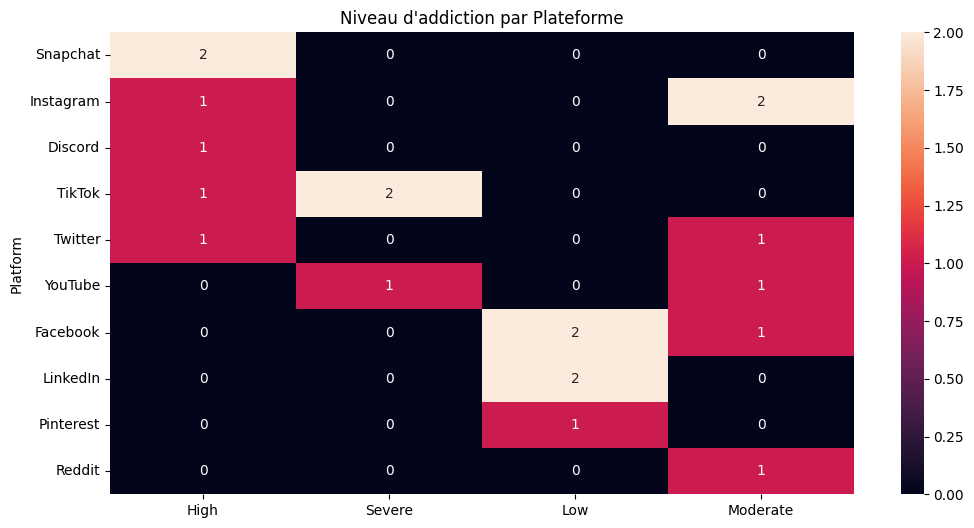

In [25]:
#Ce graphique nous montre que TikTok contient légèrement la plupart des cas d'addictions plus élevés
plt.figure(figsize=(12,6))
sns.heatmap(df_add_, annot=True, fmt=".0f")
plt.title("Niveau d'addiction par Plateforme")
plt.show()

In [26]:
df['Mental_Health_Index'].mean()

np.float64(56.75)

<function matplotlib.pyplot.show(close=None, block=None)>

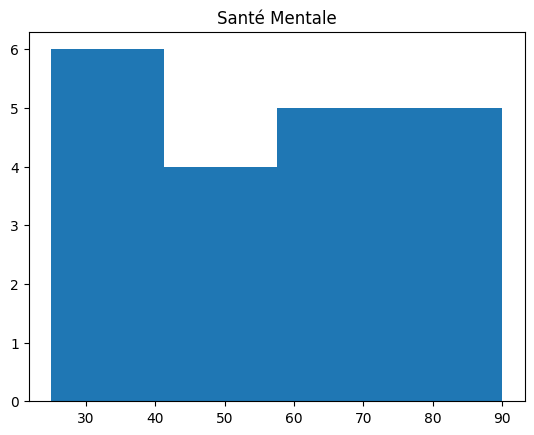

In [27]:
plt.hist(df['Mental_Health_Index'], bins = 4)
plt.title('Santé Mentale')
plt.show

In [28]:
df

,User_ID,Age,Gender,Platform,Daily_Usage_Time_min,Posts_Per_Day,Likes_Received_Daily,Comments_Received_Daily,Messages_Sent_Daily,Scroll_Rate_ppm,Addiction_Level,Emotional_State_Post_Usage,Productivity_Loss_Score,Mental_Health_Index,FOMO_Score,Classe_age,Interactions,Niveau_interaction,Niveau_usage,Niveau_Santé
0,1001,23,Female,Instagram,145,3,120,25,45,40,High,Anxious,7,45,8,Plus Jeune,193,Haute,Normal,Santé en attention
1,1002,19,Male,TikTok,210,1,45,5,10,85,Severe,Depressed,9,30,9,Plus Jeune,61,Baisse,Haute,Mauvaise Santé
2,1003,28,Female,LinkedIn,45,0,5,2,15,10,Low,Motivated,2,80,3,Adulte,22,Baisse,Baisse,Bonne santé
3,1004,35,Male,Facebook,90,2,30,10,20,25,Moderate,Neutral,4,65,5,Adulte,62,Baisse,Normal,Santé stable
4,1005,21,Non-binary,Twitter,180,15,200,60,50,55,High,Stressed,8,40,7,Plus Jeune,325,Très Haute,Haute,Mauvaise Santé
5,1006,25,Male,YouTube,240,0,10,1,0,10,Severe,Bored,9,35,4,Plus Jeune,11,Baisse,Très Haute,Mauvaise Santé
6,1007,31,Female,Instagram,60,1,50,8,30,20,Moderate,Happy,3,75,4,Adulte,89,Normal,Baisse,Bonne santé
7,1008,22,Male,TikTok,165,5,90,12,35,70,High,Envious,6,50,8,Plus Jeune,142,Normal,Haute,Santé en attention
8,1009,29,Female,Pinterest,30,0,2,0,5,15,Low,Inspired,1,85,2,Adulte,7,Baisse,Baisse,Bonne santé
9,1010,40,Male,Facebook,50,1,15,3,10,10,Low,Neutral,2,70,3,Adulte,29,Baisse,Baisse,Santé stable


In [31]:
snt = (
    df
    .groupby(['Niveau_usage','Niveau_Santé'])
    .size()
    .sort_values(ascending = False)
)
snt

Niveau_usage  Niveau_Santé      
Baisse        Bonne santé           5
Haute         Mauvaise Santé        4
Normal        Santé stable          4
              Santé en attention    2
Haute         Santé en attention    2
Très Haute    Mauvaise Santé        2
Baisse        Santé stable          1
dtype: int64

In [37]:
n_us_sn = []
us = df['Niveau_usage'].unique()

for i in us:
    us_ = snt[i]
    n_us_sn.append(us_)

n_us_sn_ = pd.DataFrame(n_us_sn)
n_us_sn_.index = us.tolist()
n_us_sn_ = n_us_sn_.fillna(0)
n_us_sn_

Niveau_Santé,Santé stable,Santé en attention,Mauvaise Santé,Bonne santé
Normal,4.0,2.0,0.0,0.0
Haute,0.0,2.0,4.0,0.0
Baisse,1.0,0.0,0.0,5.0
Très Haute,0.0,0.0,2.0,0.0


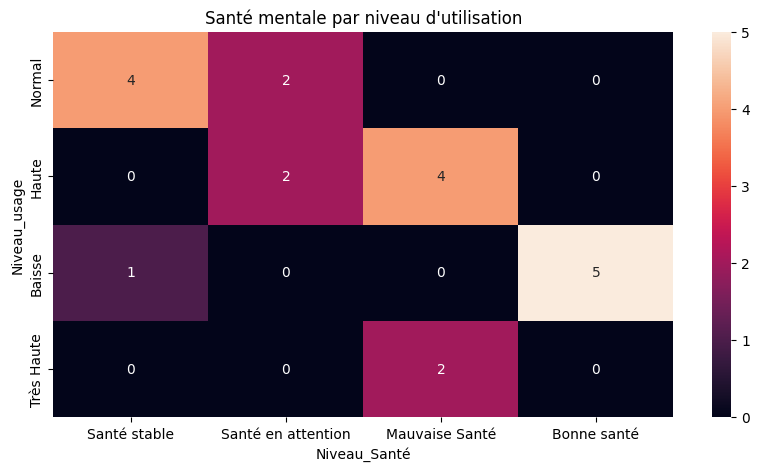

In [39]:
plt.figure(figsize = (10,5))
sns.heatmap(n_us_sn_, annot=True, fmt=".0f")
plt.ylabel('Niveau_usage')
plt.title("Santé mentale par niveau d'utilisation")
plt.show()